El objetivo de este notebook es analizar y tratar los valores ausentes de las variables meteorológicas y de irradiancia, con el fin de obtener un conjunto de datos continuo, trazable y adecuado para el posterior desarrollo de los modelos de clasificación.

Las imputaciones se realizarán únicamente cuando exista una fuente externa suficientemente compatible o un criterio físico y temporal justificable. Los valores originales se conservarán siempre que sean válidos.

In [55]:
import pandas as pd

df = pd.read_parquet('../data/processed/dataset_solar_2023_2024_v2.parquet')

numeric_columns = ['ghi', 'dni', 'dhi', 'elevacion_solar', 'temperatura', 'velocidad_viento', 'direccion_viento_sin', 'direccion_viento_cos', 'humedad_relativa']
targets = ['codigo_ghi', 'codigo_dni', 'codigo_dhi']

df.head()

,ano,mes_sin,mes_cos,dia,hora_sin,hora_cos,minuto,fecha,ghi,dni,...,elevacion_solar,periodo_solar,temperatura,velocidad_viento,humedad_relativa,direccion_viento_sin,direccion_viento_cos,codigo_ghi,codigo_dni,codigo_dhi
0,2023,0.0,1.0,1,0.0,1.0,0,2023-01-01 00:00:00,0.0,0.0,...,-74.485290,noche,10.0,1.050,77.0,0.884988,-0.465615,0,0,0
1,2023,0.0,1.0,1,0.0,1.0,1,2023-01-01 00:01:00,0.0,0.0,...,-74.564907,noche,10.0,1.333,77.0,-0.748956,0.662620,0,0,0
2,2023,0.0,1.0,1,0.0,1.0,2,2023-01-01 00:02:00,0.0,0.0,...,-74.641937,noche,10.0,1.100,77.0,-0.972031,-0.234854,0,0,0
3,2023,0.0,1.0,1,0.0,1.0,3,2023-01-01 00:03:00,0.0,0.0,...,-74.716341,noche,10.0,1.333,77.0,-0.937179,0.348850,0,0,0
4,2023,0.0,1.0,1,0.0,1.0,4,2023-01-01 00:04:00,0.0,0.0,...,-74.788081,noche,10.0,1.058,77.0,-0.443587,0.896231,0,0,0


Para las variables meteorológicas, se van a obtener los valores faltantes, y los valores para los casos donde las variables donde se pueda considerar dato inusual (como las temperaturas de -50º vistas en el dataset), mediante el uso de [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api?utm_source=chatgpt.com), dejando el resto de valores tal y como vienen al provenir de la fuente original. 

Open-Meteo dispone de una API histórica sin necesidad de API key y permite descargar, para unas coordenadas concretas, variables meteorológicas minuto a minuto, como el dataset que se tiene.

In [56]:
import numpy as np
import requests

latitude = 37.41
longitude = -6.01 

variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
]

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2023-01-01",
    "end_date": "2024-12-31",
    "hourly": ",".join(variables),
    "timezone": "Europe/Madrid"
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()

data = response.json()["hourly"]
df_weather = pd.DataFrame(data)
df_weather.head()

,time,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,wind_direction_10m
0,2023-01-01T00:00,8.6,92,23,6.9,51
1,2023-01-01T01:00,8.3,91,6,6.3,59
2,2023-01-01T02:00,8.3,89,0,6.9,62
3,2023-01-01T03:00,7.7,90,91,6.6,41
4,2023-01-01T04:00,7.5,88,79,5.9,47


In [57]:
df_weather['wind_speed_10m'] = round(df_weather['wind_speed_10m']/3.6, 3) # Paso a m/s como en el dataset original
df_weather['wind_direction_sin'] = np.sin(np.radians(df_weather['wind_direction_10m']))
df_weather['wind_direction_cos'] = np.cos(np.radians(df_weather['wind_direction_10m']))

df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather = df_weather.set_index("time")

print("Shape:", df_weather.shape)
df_weather.head()

Shape: (17544, 7)


,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,wind_direction_10m,wind_direction_sin,wind_direction_cos
time,,,,,,,
2023-01-01 00:00:00,8.6,92,23,1.917,51,0.777146,0.629320
2023-01-01 01:00:00,8.3,91,6,1.750,59,0.857167,0.515038
2023-01-01 02:00:00,8.3,89,0,1.917,62,0.882948,0.469472
2023-01-01 03:00:00,7.7,90,91,1.833,41,0.656059,0.754710
2023-01-01 04:00:00,7.5,88,79,1.639,47,0.731354,0.681998


In [58]:
df[['fecha', 'temperatura', 'humedad_relativa', 'velocidad_viento', 'direccion_viento_sin', 'direccion_viento_cos']].head()

,fecha,temperatura,humedad_relativa,velocidad_viento,direccion_viento_sin,direccion_viento_cos
0,2023-01-01 00:00:00,10.0,77.0,1.050,0.884988,-0.465615
1,2023-01-01 00:01:00,10.0,77.0,1.333,-0.748956,0.662620
2,2023-01-01 00:02:00,10.0,77.0,1.100,-0.972031,-0.234854
3,2023-01-01 00:03:00,10.0,77.0,1.333,-0.937179,0.348850
4,2023-01-01 00:04:00,10.0,77.0,1.058,-0.443587,0.896231


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

weather_map = {
    "temperatura": "temperature_2m",
    "humedad_relativa": "relative_humidity_2m",
    "velocidad_viento": "wind_speed_10m",
    "direccion_viento_sin": "wind_direction_sin",
    "direccion_viento_cos": "wind_direction_cos"
}

def weather_comparison(df, df_weather, weather_map):
    df_weather_plot = df_weather.copy()
    df_weather_plot["mes"] = df_weather_plot.index.month
    df_weather_plot["hora"] = df_weather_plot.index.hour

    df['mes'] = df['fecha'].dt.month
    df['hora'] = df['fecha'].dt.hour

    for col_es, col_en in weather_map.items():
        df_month = df.groupby("mes")[col_es].mean()
        df_hour = df.groupby("hora")[col_es].mean()
        weather_month = df_weather_plot.groupby("mes")[col_en].mean()
        weather_hour = df_weather_plot.groupby("hora")[col_en].mean()

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(df_hour.index, df_hour.values, label="df", marker="o")
        plt.plot(weather_hour.index, weather_hour.values, label="df_weather", marker="o")
        plt.title(f"Media horaria de {col_es}")
        plt.xlabel("Hora")
        plt.ylabel(col_es)
        plt.legend()
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(df_month.index, df_month.values, label="df", marker="o")
        plt.plot(weather_month.index, weather_month.values, label="df_weather", marker="o")
        plt.title(f"Media mensual de {col_es}")
        plt.xlabel("Mes")
        plt.ylabel(col_es)
        plt.xticks(range(1, 13))
        plt.legend()
        plt.grid(alpha=0.3)

        plt.suptitle(f"Comparación de medias de {col_es} entre df y df_weather", y=1.02)
        plt.tight_layout()
        plt.show()

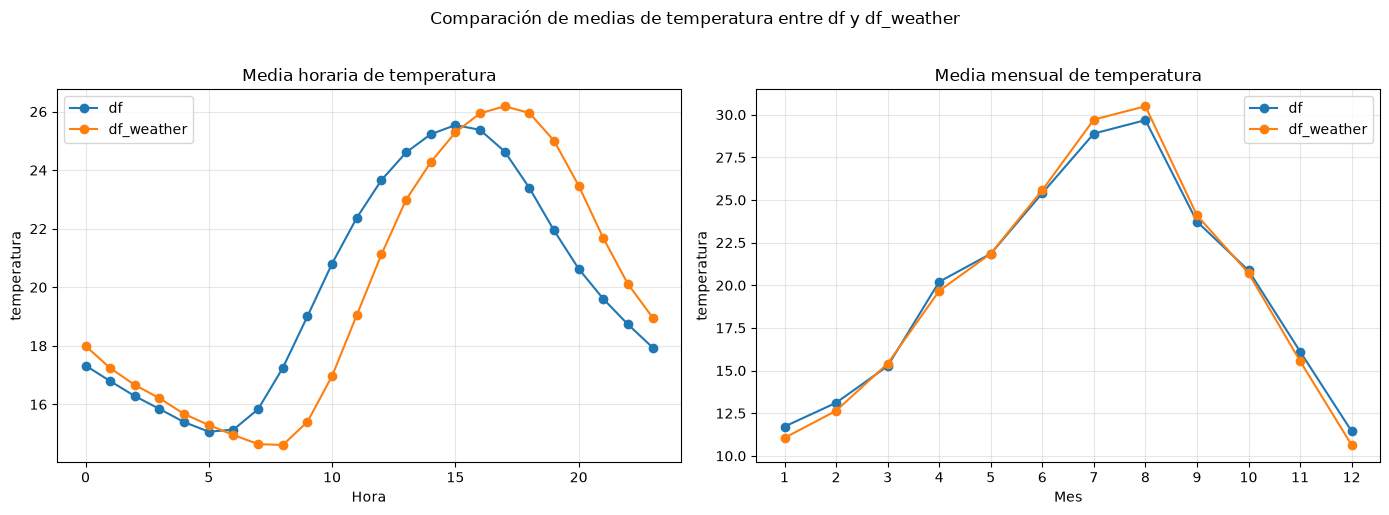

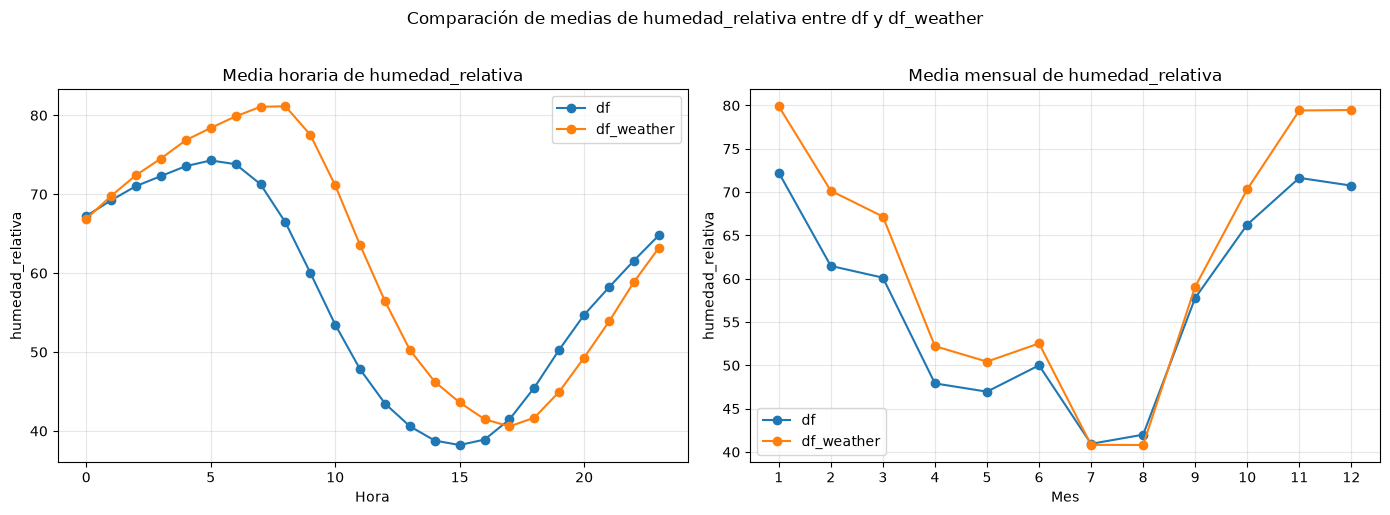

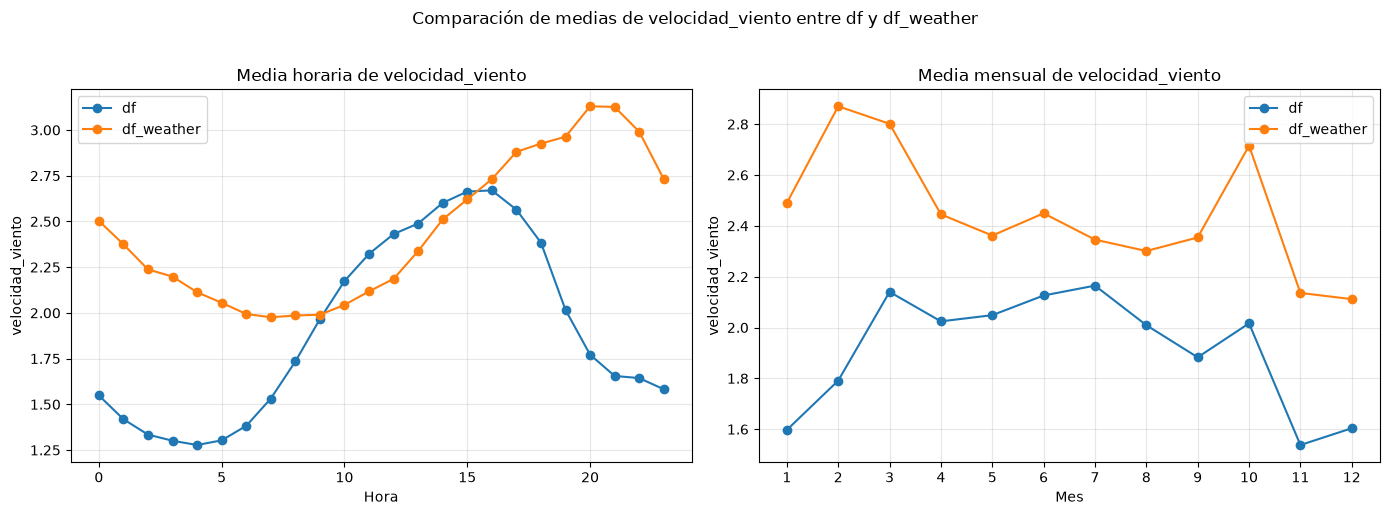

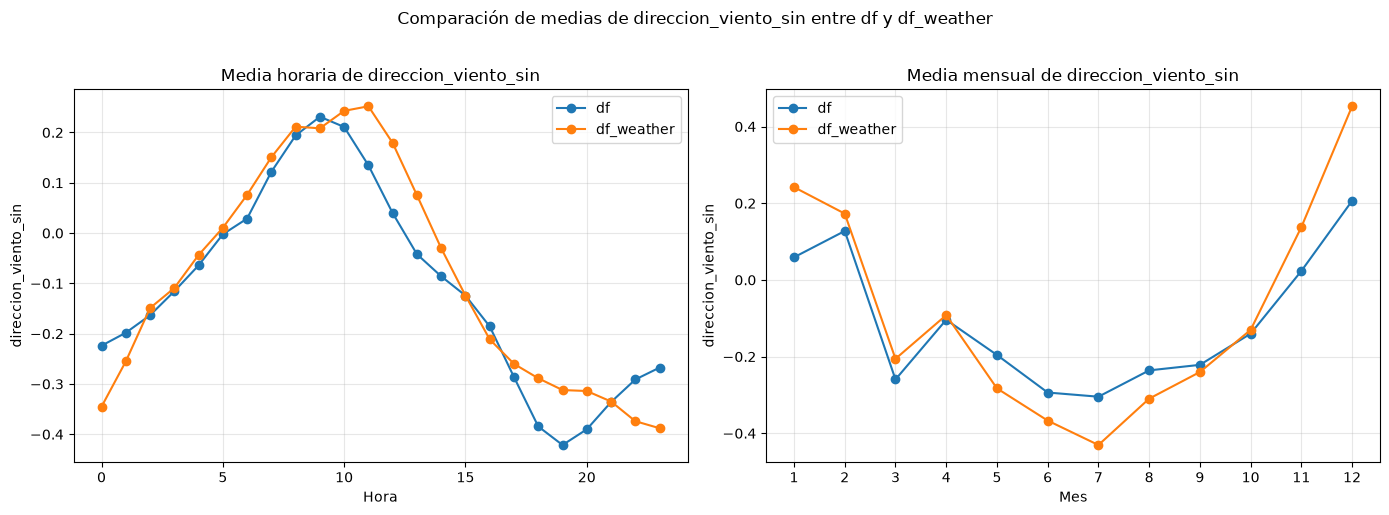

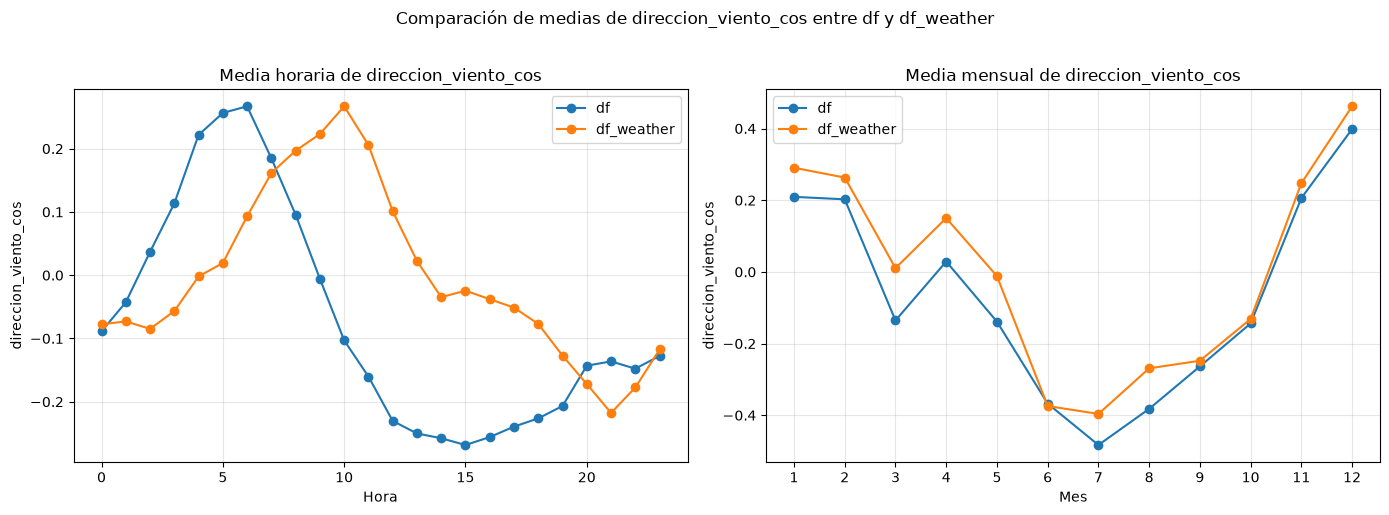

In [60]:
weather_comparison(df, df_weather, weather_map)

In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error


def compare_weather_datasets(
    df_original,
    df_api,
    column_mapping,
    original_datetime="fecha",
    api_datetime="time"
):
    """
    Compara todas las variables meteorológicas indicadas en column_mapping.

    Parameters
    ----------
    df_original : pd.DataFrame
        Dataset original con resolución minuto a minuto.

    df_api : pd.DataFrame
        Dataset obtenido mediante la API.

    column_mapping : dict
        Relación entre columnas:
        {
            "columna_original": "columna_api"
        }

    original_datetime : str
        Columna temporal del dataset original.

    api_datetime : str
        Columna temporal del dataset de la API.

    Returns
    -------
    pd.DataFrame
        MAE y RMSE para cada variable.
    """

    original = df_original.copy()
    api = df_api.copy()

    # Recuperar la fecha si está almacenada en el índice
    if original_datetime not in original.columns:
        original = original.reset_index()

    if api_datetime not in api.columns:
        api = api.reset_index()

    if original_datetime not in original.columns:
        raise KeyError(
            f"No se encuentra '{original_datetime}' en el dataset original."
        )

    if api_datetime not in api.columns:
        raise KeyError(
            f"No se encuentra '{api_datetime}' en el dataset de la API. "
            f"Columnas disponibles: {api.columns.tolist()}"
        )

    # Conversión temporal
    original[original_datetime] = pd.to_datetime(
        original[original_datetime],
        errors="coerce"
    )

    api[api_datetime] = pd.to_datetime(
        api[api_datetime],
        errors="coerce"
    )

    # Eliminar zona horaria para poder comparar
    if original[original_datetime].dt.tz is not None:
        original[original_datetime] = (
            original[original_datetime].dt.tz_localize(None)
        )

    if api[api_datetime].dt.tz is not None:
        api[api_datetime] = (
            api[api_datetime].dt.tz_localize(None)
        )

    # Agregación horaria
    original["fecha_hora"] = (
        original[original_datetime].dt.floor("h")
    )

    api["fecha_hora"] = (
        api[api_datetime].dt.floor("h")
    )

    original_columns = [
        column
        for column in column_mapping
        if column in original.columns
    ]

    api_columns = [
        column_mapping[column]
        for column in original_columns
        if column_mapping[column] in api.columns
    ]

    original_hourly = (
        original
        .groupby("fecha_hora", as_index=False)[original_columns]
        .mean()
    )

    api_hourly = (
        api
        .groupby("fecha_hora", as_index=False)[api_columns]
        .mean()
    )

    comparison = original_hourly.merge(
        api_hourly,
        on="fecha_hora",
        how="inner"
    )

    results = []

    for original_column, api_column in column_mapping.items():

        if (
            original_column not in comparison.columns
            or api_column not in comparison.columns
        ):
            continue

        valid = comparison[
            [original_column, api_column]
        ].dropna()

        if valid.empty:
            continue

        mae = mean_absolute_error(
            valid[original_column],
            valid[api_column]
        )

        rmse = np.sqrt(
            mean_squared_error(
                valid[original_column],
                valid[api_column]
            )
        )

        results.append({
            "variable": original_column,
            "variable_api": api_column,
            "n_observaciones": len(valid),
            "mae": round(mae, 3),
            "rmse": round(rmse, 3)
        })

    return pd.DataFrame(results)

In [62]:
results_openmeteo = compare_weather_datasets(
    df_original=df,
    df_api=df_weather,
    column_mapping=weather_map,
    original_datetime="fecha",
    api_datetime="time"
)

results_openmeteo

,variable,variable_api,n_observaciones,mae,rmse
0,temperatura,temperature_2m,15989,1.948,2.872
1,humedad_relativa,relative_humidity_2m,15989,9.662,12.194
2,velocidad_viento,wind_speed_10m,15989,1.045,1.334
3,direccion_viento_sin,wind_direction_sin,15989,0.428,0.579
4,direccion_viento_cos,wind_direction_cos,15989,0.427,0.590


Los datos obtenidos mediante Open-Meteo presentan diferencias apreciables respecto a las mediciones originales. Estas diferencias pueden deberse a que Open-Meteo proporciona datos procedentes de modelos o reanálisis para una celda geográfica, mientras que el dataset original contiene observaciones de una estación concreta.

Por tanto, aunque Open-Meteo puede ser útil como fuente meteorológica contextual, no se utilizará para sustituir directamente los valores ausentes del dataset original. Se buscará una fuente observacional asociada a la estación de Sevilla-Tablada o a una estación próxima.

Esta fuente alternativa va a ser utilizar la API de la AEMET, [Aemet OpenData](https://opendata.aemet.es/centrodedescargas/inicio). Esta fuente es la más fiable en el territorio español al ser la oficial, pero tiene una API más compleja de gestionar. 

In [63]:
from datetime import datetime
import meteostat as ms

stations = ms.stations.nearby(
    ms.Point(latitude, longitude),
    limit=10
)

display(
    stations[
        [
            "name",
            "country",
            "latitude",
            "longitude",
            "elevation"
        ]
    ]
)

,name,country,latitude,longitude,elevation
id,,,,,
08390,Sevilla / Tablada,ES,37.3667,-6.0000,14
08391,Sevilla / San Pablo,ES,37.4167,-5.9000,34
69669,Moron / Cortijo de Palomo,ES,37.1667,-5.6167,87
08397,Moron De La Frontera,ES,37.1500,-5.6167,87


In [64]:
station_id = stations.index[0] # Se vuelve a elegir la de Tablada

df_meteostat = ms.hourly(
    station_id,
    start=datetime(2023, 1, 1),
    end=datetime(2024, 12, 31, 23, 59),
    timezone="Europe/Madrid"
).fetch()

df_meteostat.columns

Index(['temp', 'rhum', 'prcp', 'snwd', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun',
       'cldc', 'coco'],
      dtype='str')

In [65]:
df_meteostat['wdir_sin'] = np.sin(np.radians(df_meteostat['wdir']))
df_meteostat['wdir_cos'] = np.cos(np.radians(df_meteostat['wdir']))
df_meteostat['wspd'] = round(df_meteostat['wspd']/3.6, 3) # Paso a m/s como en el dataset original

variables = ['temp', 'rhum', 'wspd', 'wdir_sin', 'wdir_cos']
df_meteostat = df_meteostat[variables]

df_meteostat.head(5)

,temp,rhum,wspd,wdir_sin,wdir_cos
time,,,,,
2023-01-01 00:00:00+01:00,10.0,78,2.056,0.642788,0.766044
2023-01-01 01:00:00+01:00,9.2,78,2.056,0.529919,0.848048
2023-01-01 02:00:00+01:00,8.7,79,2.056,0.559193,0.829038
2023-01-01 03:00:00+01:00,7.2,85,2.583,0.587785,0.809017
2023-01-01 04:00:00+01:00,6.6,86,2.056,0.573576,0.819152


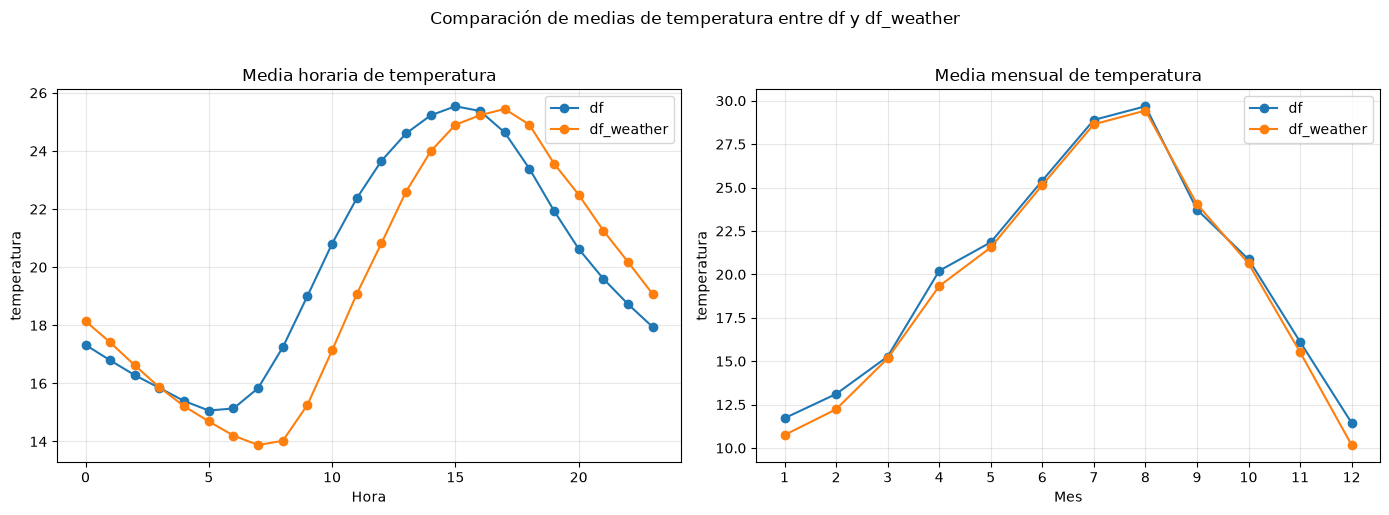

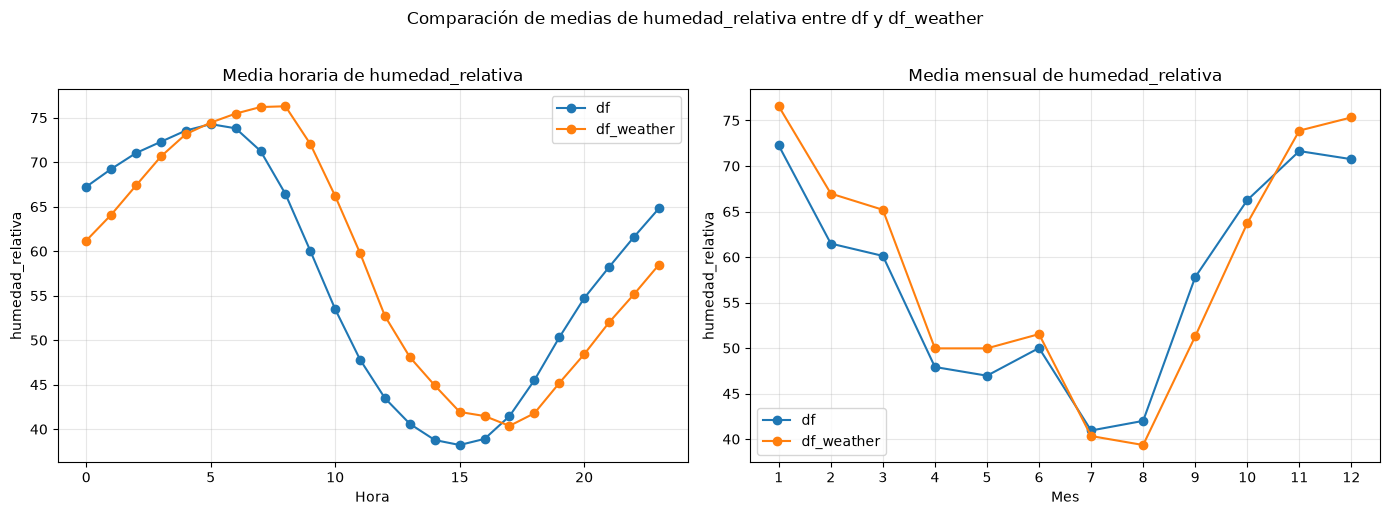

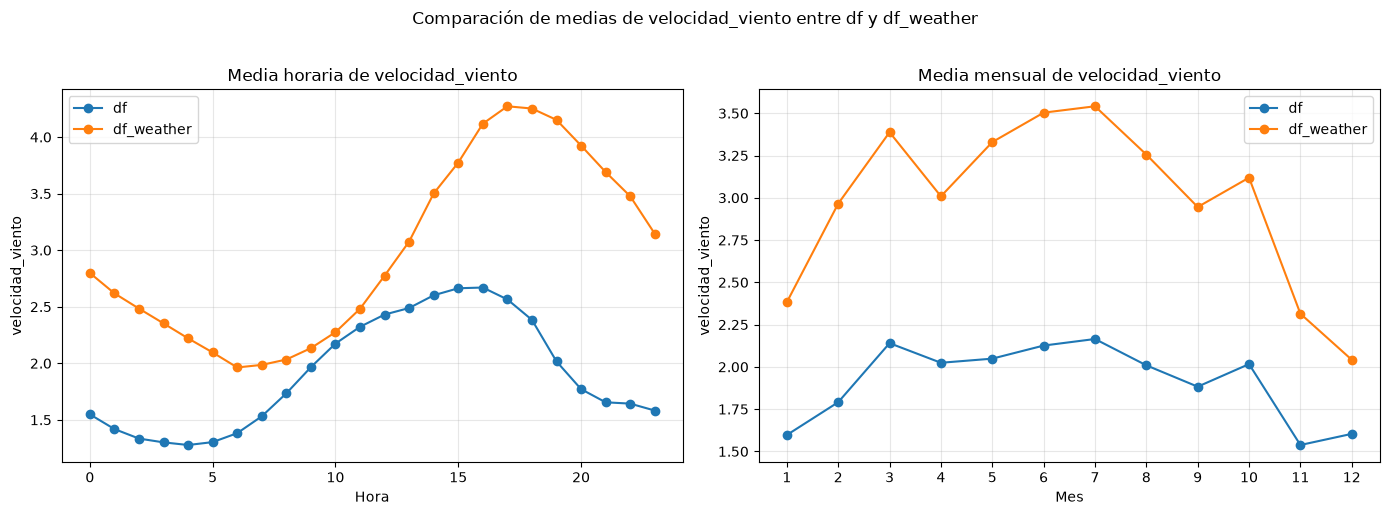

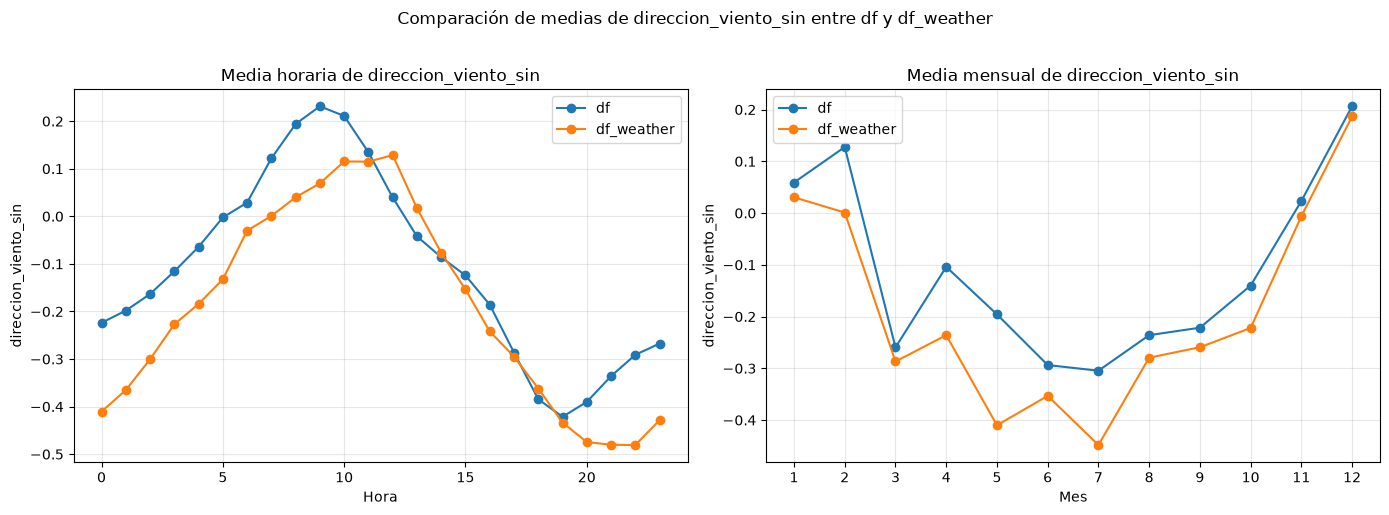

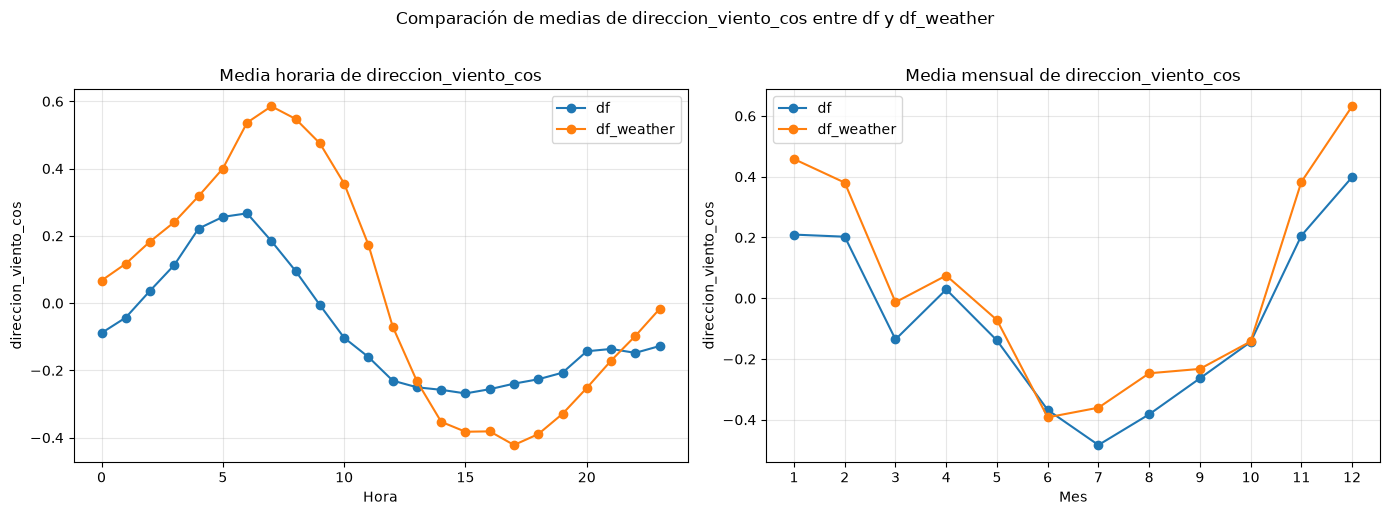

In [66]:
meteostat_map = {
    "temperatura": "temp",
    "humedad_relativa": "rhum",
    "velocidad_viento": "wspd",
    "direccion_viento_sin": "wdir_sin",
    "direccion_viento_cos": "wdir_cos"
}

weather_comparison(df, df_weather=df_meteostat, weather_map= meteostat_map)

In [67]:
results_meteostat = compare_weather_datasets(
    df_original=df,
    df_api=df_meteostat,
    column_mapping=meteostat_map,
    original_datetime="fecha",
    api_datetime="time"
)

results_meteostat

,variable,variable_api,n_observaciones,mae,rmse
0,temperatura,temp,15987,2.026,2.920
1,humedad_relativa,rhum,15987,9.976,12.478
2,velocidad_viento,wspd,15987,1.299,1.746
3,direccion_viento_sin,wdir_sin,15987,0.401,0.531
4,direccion_viento_cos,wdir_cos,15987,0.433,0.568


Las dos librerías utilizadas para la imputación de las variables meteorológicas tienen los siguientes problemas:

- Tienen mediciones cada hora, lo que hace que no tenga la misma frecuencia que el dataset, el cual tiene mediciones por minuto
- La media horaria de cada una de las variables presenta grandes variaciones con respecto a la del dataset original, perdiendo por lo tanto fiabilidad si se usa para imputar nulos en el dataset.
- La estación meteorológica usada en las librerías se encuentra en Tablada mientras que los datos obtenidos en el dataset son de la estación que se encuentra en la ETSI de la Universidad de Sevilla.

De esta manera, se va a estudiar el uso de técnicas de imputación temporales para huecos cortos y moderados, estudiando los diferentes casos para cada variable. Para ello, se va a revisar los huecos de información para saber cuántos existen y el tiempo existente sin información

In [68]:
def detect_gaps(serie):
    mask_bool = serie.isna().to_numpy()

    starts = np.flatnonzero(mask_bool & ~np.r_[False, mask_bool[:-1]])
    ends = np.flatnonzero(mask_bool & ~np.r_[mask_bool[1:], False])

    gaps = pd.DataFrame({
        "start_idx": starts,
        "end_idx": ends,
        "length_h": np.round((ends - starts + 1) / 60, 2)
    })

    gaps["start_time"] = df["fecha"].iloc[gaps["start_idx"]].values
    gaps["end_time"] = df["fecha"].iloc[gaps["end_idx"]].values

    gaps = (
        gaps[["start_time", "end_time", "length_h"]]
        .sort_values("length_h", ascending=False)
        .reset_index(drop=True)
    )

    print(f"Número total de gaps de nulos: {len(gaps)}")
    print(f"Máximo tramo: {gaps.iloc[0]['length_h']} horas")
    print(f"Media de tiempo de los gaps (min):", round(gaps['length_h'].mean() * 60, 2))
    print(f"Desde {gaps.iloc[0]['start_time']} hasta {gaps.iloc[0]['end_time']}")
    display(gaps.head(10))

    return gaps

In [69]:
gaps = detect_gaps(df['temperatura'])

Número total de gaps de nulos: 145
Máximo tramo: 376.05 horas
Media de tiempo de los gaps (min): 656.4
Desde 2024-09-02 17:29:00 hasta 2024-09-18 09:31:00


,start_time,end_time,length_h
0,2024-09-02 17:29:00,2024-09-18 09:31:00,376.05
1,2023-04-04 00:00:00,2023-04-09 23:59:00,144.00
2,2024-03-13 09:31:00,2024-03-18 17:58:00,128.47
3,2024-12-11 18:29:00,2024-12-16 10:10:00,111.70
4,2024-03-22 13:11:00,2024-03-26 18:22:00,101.20
5,2024-07-27 06:37:00,2024-07-31 11:02:00,100.43
6,2024-11-14 18:29:00,2024-11-18 12:40:00,90.20
7,2024-02-24 00:00:00,2024-02-27 09:21:00,81.37
8,2023-07-15 06:51:00,2023-07-18 08:19:00,73.48
9,2023-03-11 07:51:00,2023-03-14 08:32:00,72.70


Existen gaps de más de 16 días y el top 10 son todos gaps de más de 3 días. Esto hace que no se puedan imputar correctamente estas variables usando técnicas de imputación temporal ya que se pierde la información durante varios días completos. Además, la dirección y velocidad del viento son variables que varían considerablemente minuto a minuto por lo que se dificulta aún más esta tarea de imputación.

Por tanto, se van a estudiar gaps de temperatura y humedad de hasta 3 horas y gaps de variables asociadas al viento de hasta 30 min debido a mayor variabilidad. 

In [70]:
def gaps_under_time(gaps, time_h=1):
    gaps_short = gaps[gaps['length_h'] < time_h]
    print(f"Número de gaps < {time_h} horas: {len(gaps_short)}")
    print(f"Porcentaje del total: {len(gaps_short) / len(gaps) * 100:.2f}%")

    print(f"Top 10 gaps < {time_h} horas:")
    print(gaps_short.head(10))
    print()
    return gaps_short


In [71]:
# Gaps de temperatura < 3 horas
temp_gaps_short = gaps_under_time(gaps, 3)

# Gaps de viento < 30 minutos (0.5 horas)
wind_gaps_short = gaps_under_time(gaps, 0.5)

Número de gaps < 3 horas: 122
Porcentaje del total: 84.14%
Top 10 gaps < 3 horas:
            start_time            end_time  length_h
23 2024-04-26 08:28:00 2024-04-26 09:24:00      0.95
24 2024-03-22 12:10:00 2024-03-22 12:33:00      0.40
25 2024-03-22 11:37:00 2024-03-22 11:55:00      0.32
26 2024-03-22 12:49:00 2024-03-22 13:02:00      0.23
27 2024-03-13 09:15:00 2024-03-13 09:28:00      0.23
28 2024-03-26 18:27:00 2024-03-26 18:36:00      0.17
29 2024-04-13 08:04:00 2024-04-13 08:10:00      0.12
30 2023-06-07 08:51:00 2023-06-07 08:57:00      0.12
31 2024-03-20 16:11:00 2024-03-20 16:17:00      0.12
32 2024-04-15 13:20:00 2024-04-15 13:26:00      0.12

Número de gaps < 0.5 horas: 121
Porcentaje del total: 83.45%
Top 10 gaps < 0.5 horas:
            start_time            end_time  length_h
24 2024-03-22 12:10:00 2024-03-22 12:33:00      0.40
25 2024-03-22 11:37:00 2024-03-22 11:55:00      0.32
26 2024-03-22 12:49:00 2024-03-22 13:02:00      0.23
27 2024-03-13 09:15:00 2024-03-13 09

Solo existen un gap que se encuentre entre 30 minutos y 3 horas por lo que se tienen prácticamente el mismo número de gaps a tratar para el caso de temperatura y humedad y las variables asociadas al viento. 

De esta manera, para los gaps de menos de 30 min 

In [72]:
def interpolate_short_gaps(series, max_gap):
    is_nan = series.isna()
    gap_id = is_nan.ne(is_nan.shift()).cumsum()
    gap_size = is_nan.groupby(gap_id).transform("sum")

    interpolated = series.interpolate(
        method="linear",
        limit_area="inside"
    )

    return series.where(~is_nan | (gap_size > max_gap), interpolated)


In [73]:
# Frecuencia del dataset: 1 minuto
df["temperatura"] = interpolate_short_gaps(
    df["temperatura"],
    max_gap=60*3
)

df["humedad_relativa"] = interpolate_short_gaps(
    df["humedad_relativa"],
    max_gap=60*3
)

df["velocidad_viento"] = interpolate_short_gaps(
    df["velocidad_viento"],
    max_gap=30
)

df["direccion_viento_cos"] = interpolate_short_gaps(
    df["direccion_viento_cos"],
    max_gap=30
)

df["direccion_viento_sin"] = interpolate_short_gaps(
    df["direccion_viento_sin"],
    max_gap=30
)

Volvemos a comprobar el número de gaps restantes una vez realizado la imputación

In [74]:
# Número de gaps de temperatura y humedad restantes
temp_hum_gaps = detect_gaps(df['temperatura'])

# Número de gaps de variables de viento
wind_gaps = detect_gaps(df['velocidad_viento'])

Número total de gaps de nulos: 23
Máximo tramo: 376.05 horas
Media de tiempo de los gaps (min): 4109.24
Desde 2024-09-02 17:29:00 hasta 2024-09-18 09:31:00


,start_time,end_time,length_h
0,2024-09-02 17:29:00,2024-09-18 09:31:00,376.05
1,2023-04-04 00:00:00,2023-04-09 23:59:00,144.00
2,2024-03-13 09:31:00,2024-03-18 17:58:00,128.47
3,2024-12-11 18:29:00,2024-12-16 10:10:00,111.70
4,2024-03-22 13:11:00,2024-03-26 18:22:00,101.20
5,2024-07-27 06:37:00,2024-07-31 11:02:00,100.43
6,2024-11-14 18:29:00,2024-11-18 12:40:00,90.20
7,2024-02-24 00:00:00,2024-02-27 09:21:00,81.37
8,2023-07-15 06:51:00,2023-07-18 08:19:00,73.48
9,2023-03-11 07:51:00,2023-03-14 08:32:00,72.70


Número total de gaps de nulos: 24
Máximo tramo: 376.05 horas
Media de tiempo de los gaps (min): 3940.4
Desde 2024-09-02 17:29:00 hasta 2024-09-18 09:31:00


,start_time,end_time,length_h
0,2024-09-02 17:29:00,2024-09-18 09:31:00,376.05
1,2023-04-04 00:00:00,2023-04-09 23:59:00,144.00
2,2024-03-13 09:31:00,2024-03-18 17:58:00,128.47
3,2024-12-11 18:29:00,2024-12-16 10:10:00,111.70
4,2024-03-22 13:11:00,2024-03-26 18:22:00,101.20
5,2024-07-27 06:37:00,2024-07-31 11:02:00,100.43
6,2024-11-14 18:29:00,2024-11-18 12:40:00,90.20
7,2024-02-24 00:00:00,2024-02-27 09:21:00,81.37
8,2023-07-15 06:51:00,2023-07-18 08:19:00,73.48
9,2023-03-11 07:51:00,2023-03-14 08:32:00,72.70
